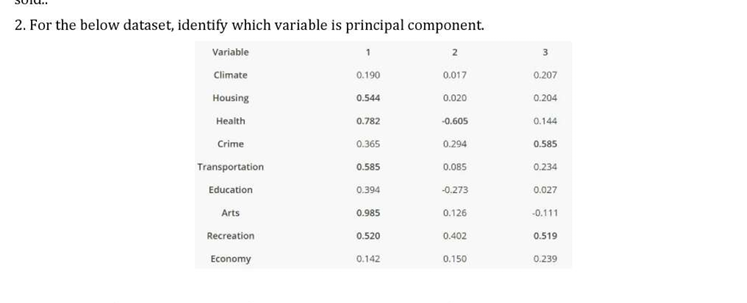

In [5]:
import pandas as pd
import numpy as np

data = {
    'Variable': [
        'Climate',
        'Housing',
        'Health',
        'Crime',
        'Transportation',
        'Education',
        'Arts',
        'Recreation',
        'Economy'
    ],

    'PC1': [
        0.190,
        0.544,
        0.782,
        0.365,
        0.585,
        0.394,
        0.985,
        0.520,
        0.142
    ],

    'PC2': [
        0.017,
        0.020,
        -0.605,
        0.294,
        0.085,
        -0.273,
        0.126,
        0.402,
        0.150
    ],

    'PC3': [
        0.207,
        0.204,
        0.144,
        0.585,
        0.234,
        0.027,
        -0.111,
        0.519,
        0.239
    ]
}

df = pd.DataFrame(data)

print("Principal Component Dataset")
print("=" * 60)
print(df.to_string(index=False))

Principal Component Dataset
      Variable   PC1    PC2    PC3
       Climate 0.190  0.017  0.207
       Housing 0.544  0.020  0.204
        Health 0.782 -0.605  0.144
         Crime 0.365  0.294  0.585
Transportation 0.585  0.085  0.234
     Education 0.394 -0.273  0.027
          Arts 0.985  0.126 -0.111
    Recreation 0.520  0.402  0.519
       Economy 0.142  0.150  0.239


In [6]:
for pc in ['PC1', 'PC2', 'PC3']:

    df['Absolute_' + pc] = df[pc].abs()

    index = df['Absolute_' + pc].idxmax()

    variable = df.loc[index, 'Variable']
    value = df.loc[index, pc]

    print("\n", pc)
    print("-" * 30)
    print("Principal Variable :", variable)
    print("Loading            :", value)
    print("Absolute Loading   :", abs(value))


 PC1
------------------------------
Principal Variable : Arts
Loading            : 0.985
Absolute Loading   : 0.985

 PC2
------------------------------
Principal Variable : Health
Loading            : -0.605
Absolute Loading   : 0.605

 PC3
------------------------------
Principal Variable : Crime
Loading            : 0.585
Absolute Loading   : 0.585


In [7]:
for pc in ['PC1', 'PC2', 'PC3']:

    print("\n" + "=" * 60)
    print("VARIABLE CONTRIBUTIONS FOR", pc)
    print("=" * 60)

    result = df[['Variable', pc]].copy()

    result['Absolute Loading'] = result[pc].abs()

    result = result.sort_values(
        by='Absolute Loading',
        ascending=False
    )

    print(result.to_string(index=False))


VARIABLE CONTRIBUTIONS FOR PC1
      Variable   PC1  Absolute Loading
          Arts 0.985             0.985
        Health 0.782             0.782
Transportation 0.585             0.585
       Housing 0.544             0.544
    Recreation 0.520             0.520
     Education 0.394             0.394
         Crime 0.365             0.365
       Climate 0.190             0.190
       Economy 0.142             0.142

VARIABLE CONTRIBUTIONS FOR PC2
      Variable    PC2  Absolute Loading
        Health -0.605             0.605
    Recreation  0.402             0.402
         Crime  0.294             0.294
     Education -0.273             0.273
       Economy  0.150             0.150
          Arts  0.126             0.126
Transportation  0.085             0.085
       Housing  0.020             0.020
       Climate  0.017             0.017

VARIABLE CONTRIBUTIONS FOR PC3
      Variable    PC3  Absolute Loading
         Crime  0.585             0.585
    Recreation  0.519             

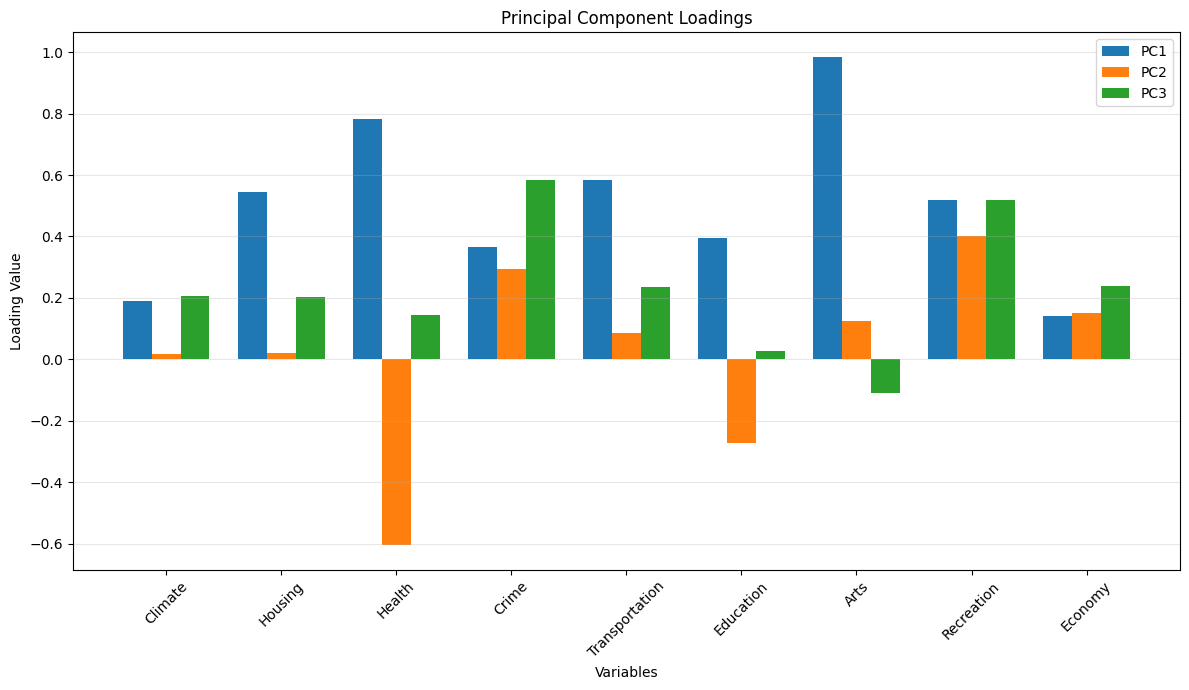

In [8]:
import matplotlib.pyplot as plt

variables = df['Variable']

x = np.arange(len(variables))
width = 0.25

plt.figure(figsize=(12, 7))

plt.bar(x - width, df['PC1'], width, label='PC1')
plt.bar(x, df['PC2'], width, label='PC2')
plt.bar(x + width, df['PC3'], width, label='PC3')

plt.xticks(x, variables, rotation=45)
plt.xlabel("Variables")
plt.ylabel("Loading Value")
plt.title("Principal Component Loadings")
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()